# Credit Risk Prediction - Model Interpretability

SHAP analysis for the best performing model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Load Data & Best Model

In [2]:
df = pd.read_excel('../data/raw/default of credit card clients.xls', header=1, engine='xlrd')
df.rename(columns={'default payment next month': 'default'}, inplace=True)
df.drop('ID', axis=1, inplace=True)

TARGET = 'default'
X = df.drop(TARGET, axis=1)
y = df[TARGET]

# Feature engineering (same as modeling notebook)
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
X['avg_delay'] = X[pay_cols].mean(axis=1)
X['max_delay'] = X[pay_cols].max(axis=1)
X['delay_std'] = X[pay_cols].std(axis=1)
X['total_delay_months'] = (X[pay_cols] > 0).sum(axis=1)

bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
X['avg_bill'] = X[bill_cols].mean(axis=1)
X['bill_trend'] = X['BILL_AMT1'] - X['BILL_AMT6']

pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
X['avg_pay_amt'] = X[pay_amt_cols].mean(axis=1)
X['pay_ratio'] = X['avg_pay_amt'] / (X['avg_bill'] + 1)
X['credit_util'] = X['BILL_AMT1'] / (X['LIMIT_BAL'] + 1)

# Winsorize
def winsorize(series, lower=0.01, upper=0.99):
    return series.clip(series.quantile(lower), series.quantile(upper))

X.fillna(0, inplace=True)
for col in X.select_dtypes(include=[np.number]).columns:
    X[col] = winsorize(X[col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

# Load best model (try each)
model_names = ['lightgbm', 'xgboost', 'random_forest', 'logistic_regression']
best_model = None
for name in model_names:
    try:
        best_model = joblib.load(f'../models/{name}.pkl')
        print(f"Loaded model: {name}")
        break
    except FileNotFoundError:
        continue

if best_model is None:
    raise FileNotFoundError("No trained models found. Run 02_Modeling.ipynb first.")


Loaded model: lightgbm


## 2. SHAP Summary Plot

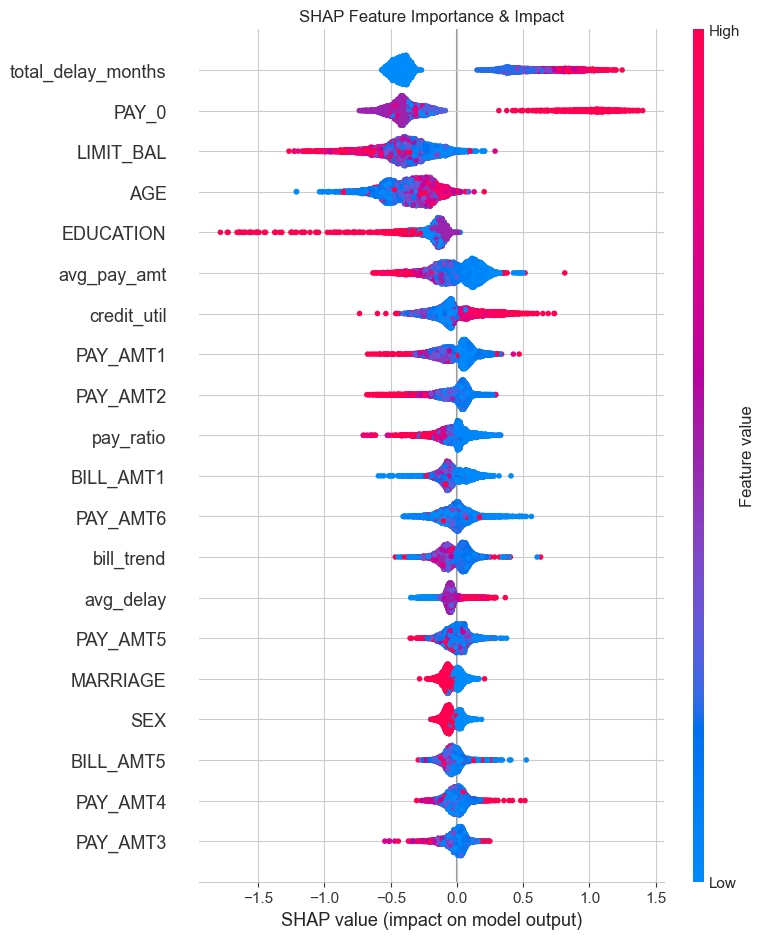

In [3]:
explainer = shap.TreeExplainer(best_model) if hasattr(best_model, 'feature_importances_') else shap.Explainer(best_model, X_train_sm)
shap_values = explainer(X_test_scaled)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title('SHAP Feature Importance & Impact')
plt.tight_layout()
plt.savefig('../reports/figures/10_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. SHAP Bar Plot (Feature Importance)

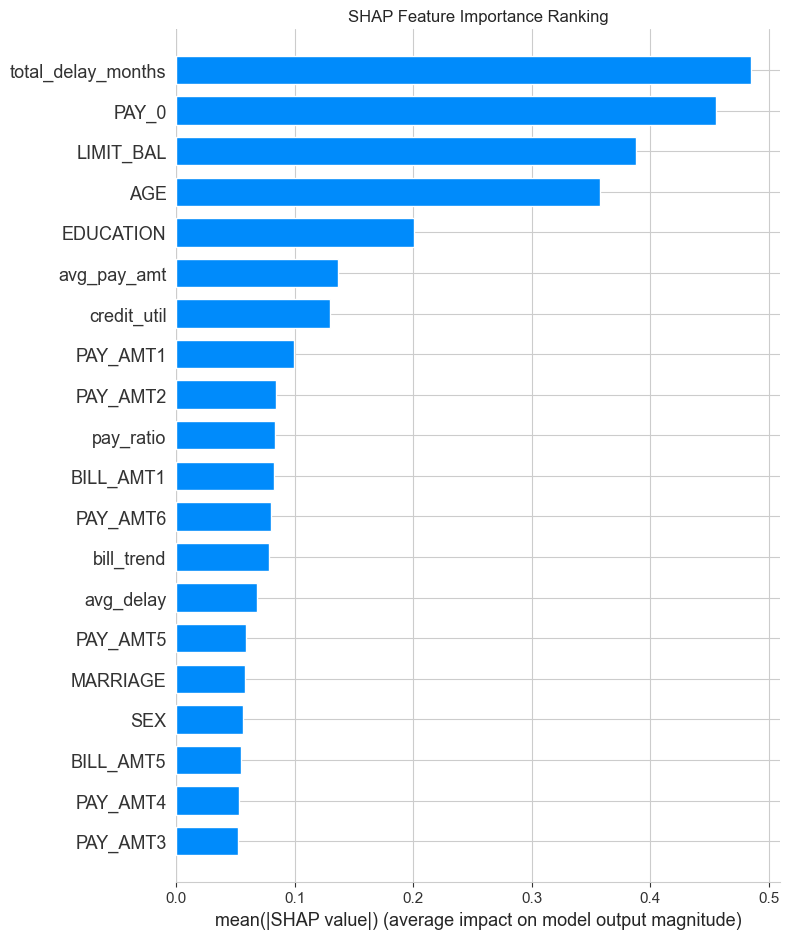

In [4]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, plot_type='bar', show=False)
plt.title('SHAP Feature Importance Ranking')
plt.tight_layout()
plt.savefig('../reports/figures/11_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. SHAP Dependence Plots

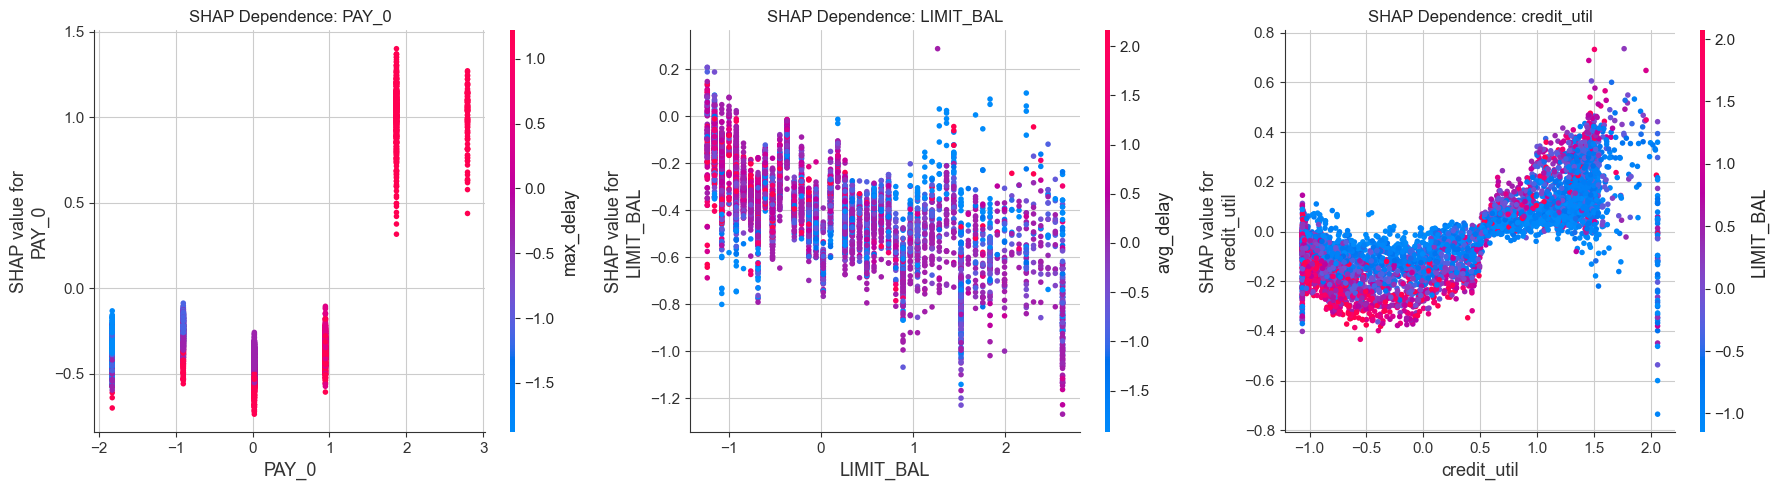

In [5]:
top_features = ['PAY_0', 'LIMIT_BAL', 'credit_util', 'avg_delay', 'BILL_AMT1']
fig, axes = plt.subplots(1, min(3, len(top_features)), figsize=(18, 5))

for i, feat in enumerate(top_features[:3]):
    shap.dependence_plot(feat, shap_values.values, X_test_scaled, ax=axes[i], show=False)
    axes[i].set_title(f'SHAP Dependence: {feat}')

plt.tight_layout()
plt.savefig('../reports/figures/12_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Individual Prediction Explanation

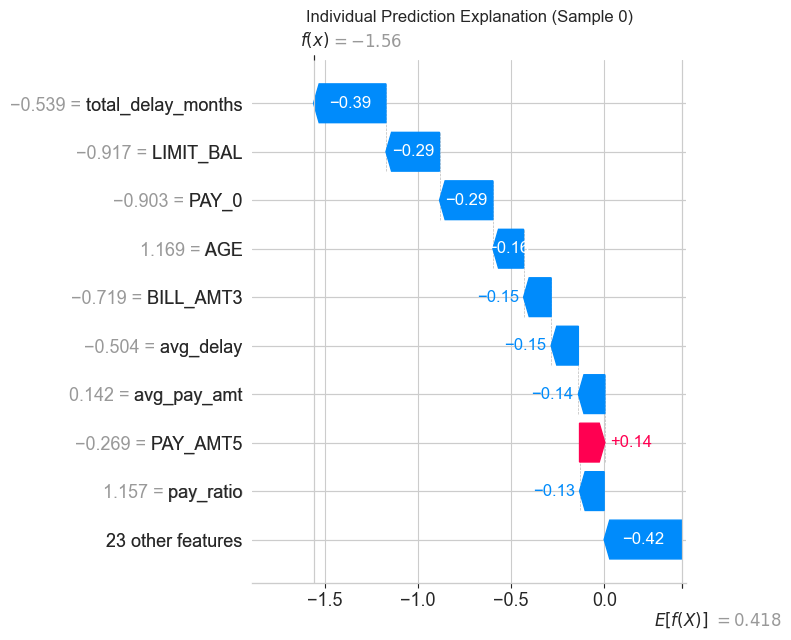

Actual: No Default
Predicted probability: 0.1737


In [6]:
sample_idx = 0
plt.figure(figsize=(12, 4))
shap.waterfall_plot(shap_values[sample_idx], show=False)
plt.title(f'Individual Prediction Explanation (Sample {sample_idx})')
plt.tight_layout()
plt.savefig('../reports/figures/13_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Actual: {'Default' if y_test.iloc[sample_idx] == 1 else 'No Default'}")
print(f"Predicted probability: {best_model.predict_proba(X_test_scaled.iloc[[sample_idx]])[0, 1]:.4f}")


## 6. SHAP Force Plot

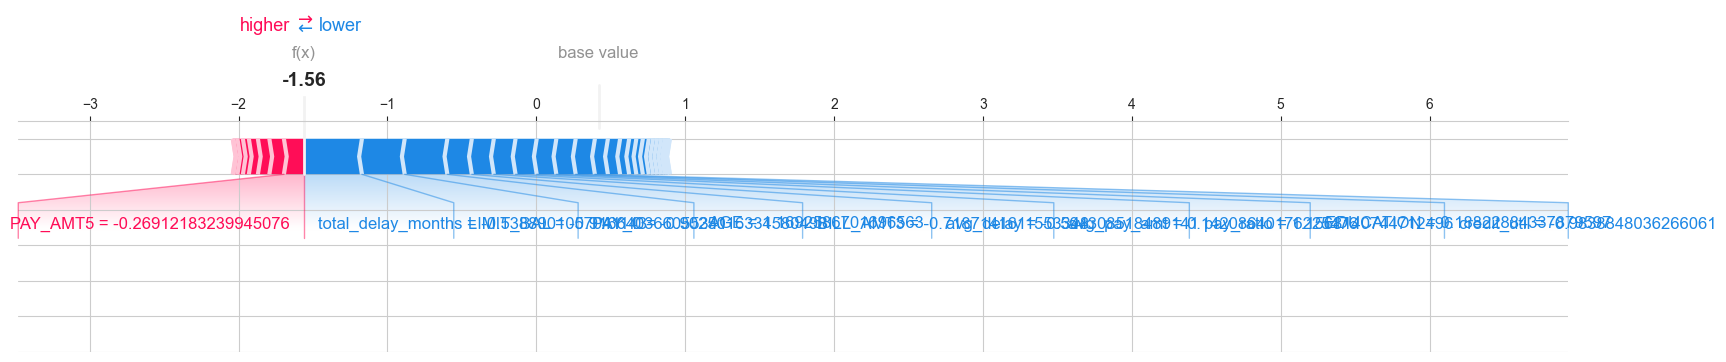

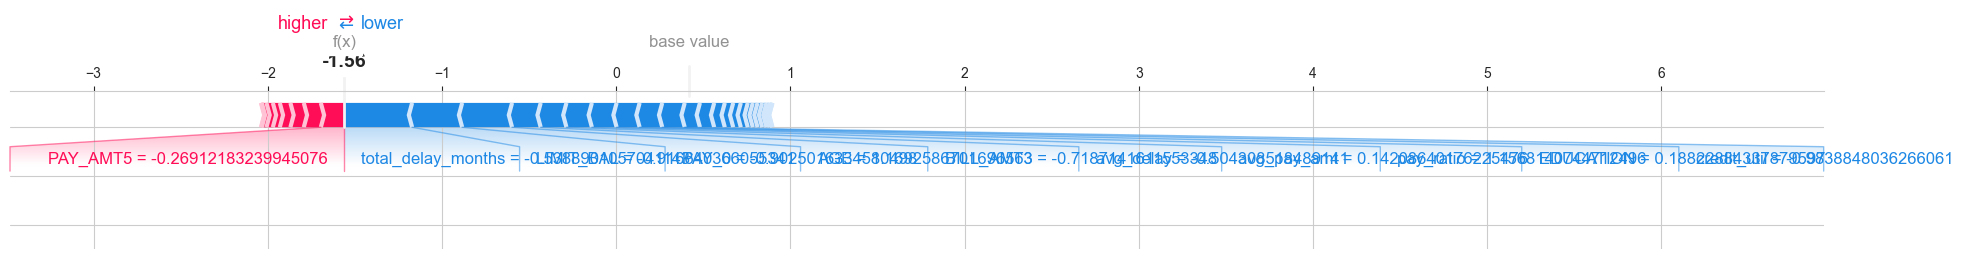

In [7]:
shap.initjs()
display(shap.force_plot(
    shap_values[sample_idx].base_values,
    shap_values[sample_idx].values,
    X_test_scaled.iloc[sample_idx],
    matplotlib=True,
    show=False
))
plt.tight_layout()
plt.savefig('../reports/figures/14_shap_force.png', dpi=150, bbox_inches='tight')
plt.show()
